# Load Modules and Functions

In [35]:
import os
import sys
from copy import deepcopy
import pickle
import re

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import expon, norm, beta
from scipy.ndimage import gaussian_filter
import matplotlib.transforms as mtransforms
from tqdm import tqdm
from sklearn.metrics import pairwise_distances
import Bio.Phylo

# install PyFish via https://bitbucket.org/schwarzlab/pyfish
import pyfish
from pyfish.core import *

# Local scripts
sys.path.append('scripts/')
from plotting import *

%matplotlib inline

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
set_plotting_params()
if not os.path.exists('final_figures'):
    os.mkdir('final_figures')

In [38]:
topx = 25
topy = 400
linex = np.linspace(1, topx, 19000)
sweeps_func = lambda n: 1 / ((n % 1 - 1)**2 + (n % 1)**2)
def intermediate_curve(n):
    if n == 1:
        return np.array([1])
    q = np.ceil(3 * n - 2)
    return 2/((q-1)*q) * (2*q-3*n+1+3*(2*n-q-1)*(np.arange(q)+1)/(q+1))
def get_D(ff):
    ff = np.sort(ff / np.sum(ff))[::-1]
    D = 1/np.sum(ff**2)
    return D

int_curve_ = np.array([intermediate_curve(n) for n in linex])
int_curve = np.array([get_D(ff) for ff in int_curve_])

maxy = np.ones_like(linex)
maxy[linex < 2] = 1 / (2 - linex[linex < 2])**2

<ipython-input-38-513b4e44a15e>:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  int_curve_ = np.array([intermediate_curve(n) for n in linex])


# Load data
To create plotting data from raw data see smith/notebooks/scripts/create_plotting_from_raw.py

## Our simulation results

In [39]:
confinement_data_df = pd.read_pickle('data/main_data.pkl')
fitness_dist_data = pd.read_pickle('data/fitness_dist_data.pkl')
fitness_acc_data = pd.read_pickle('data/fitness_acc_data.pkl')
most_representative_runs = pd.read_pickle('data/most_representative_runs.pkl')

with open('data/metrics_over_time.pkl', 'rb') as f:
    all_metrics_over_time = pickle.load(f)
with open('data/tree_data.pkl', 'rb') as f:
    tree_data = pickle.load(f)

if os.path.exists('data/trajectories.pkl'):
    with open('data/trajectories.pkl', 'rb') as f:
        trajectories = pickle.load(f)
else:
    trajectories = dict()

if os.path.exists('data/fish_plot_data.pkl'):
    with open('data/fish_plot_data.pkl', 'rb') as f:
        fish_plot_data = pickle.load(f)
else:
    fish_plot_data = dict()

range_MutationProb = [0.000001, 0.000005, 0.00001, 0.00005, 0.0001]
range_FitnessMean = [0.01, 0.05, 0.1, 0.15, 0.2]

## Load Noble et al. 2022 Data and Recreate Figures

In [40]:
real_data = pd.read_pickle('data/noble_2022_real_data.pkl')
noble_combined = pd.read_pickle('data/noble_2022_simulations.pkl')
datasets = ['AML', 'kidney', 'mesothelioma', 'breast_SC', 'lung', 'uveal']

# Noble et al. 2022 Summary statistics

In [41]:
noble_combined.loc[noble_combined['label']=='invasive_glandular', 'Sweep'].sum() / len(noble_combined.loc[noble_combined['label']=='invasive_glandular'])

0.015925925925925927

In [42]:
real_data.groupby('dataset').mean().loc[datasets]

,n,D
dataset,,
AML,2.561260,2.219014
kidney,5.390433,3.942204
mesothelioma,6.431351,3.986781
breast_SC,5.176277,7.641952
lung,6.617524,7.704800
uveal,10.424542,3.820132


In [43]:
real_data.groupby('dataset').median().loc[datasets]


,n,D
dataset,,
AML,2.435842,2.304832
kidney,5.250000,2.951220
mesothelioma,5.796337,4.139901
breast_SC,4.896633,8.049273
lung,6.004286,8.079357
uveal,11.200820,3.574409


# Number of sweeps

In [44]:
confinement_data_df.loc[(confinement_data_df['MutationProb'] == 10**-5) &
                        (confinement_data_df['FitnessMean'] == 0.1) &
                        (confinement_data_df['Confinement_global'] == 0.5) &
                        (confinement_data_df['Confinement_local'] == 0.0), 'Sweep'].sum() / 100


0.39

In [45]:
confinement_data_df.loc[(confinement_data_df['MutationProb'] == 10**-5) &
                        (confinement_data_df['FitnessMean'] == 0.1)].groupby(
                            ['Confinement_global', 'Confinement_local'])['Sweep'].sum() / 100

Confinement_global  Confinement_local
0.0000              0.0000               0.56
                    0.0625               0.00
                    0.1250               0.00
                    0.2500               0.00
                    0.5000               0.00
0.0625              0.0000               0.42
                    0.0625               0.00
                    0.1250               0.00
                    0.2500               0.00
                    0.5000               0.00
0.1250              0.0000               0.40
                    0.0625               0.00
                    0.1250               0.00
                    0.2500               0.00
                    0.5000               0.00
0.2500              0.0000               0.39
                    0.0625               0.12
                    0.1250               0.00
                    0.2500               0.00
                    0.5000               0.00
0.5000              0.0000               0

# Effect of global and local confinement on mean drivers per cell and clonal diversity

In [46]:
selection_confinement_global = [0, 0.0625, 0.125, 0.5, 1, 2.0]
selection_confinement_local = [0, 0.0625, 0.125, 0.25, 0.5]
local_markers = ['o', 'X', 's', 'D', 'P', 'v', 'd']

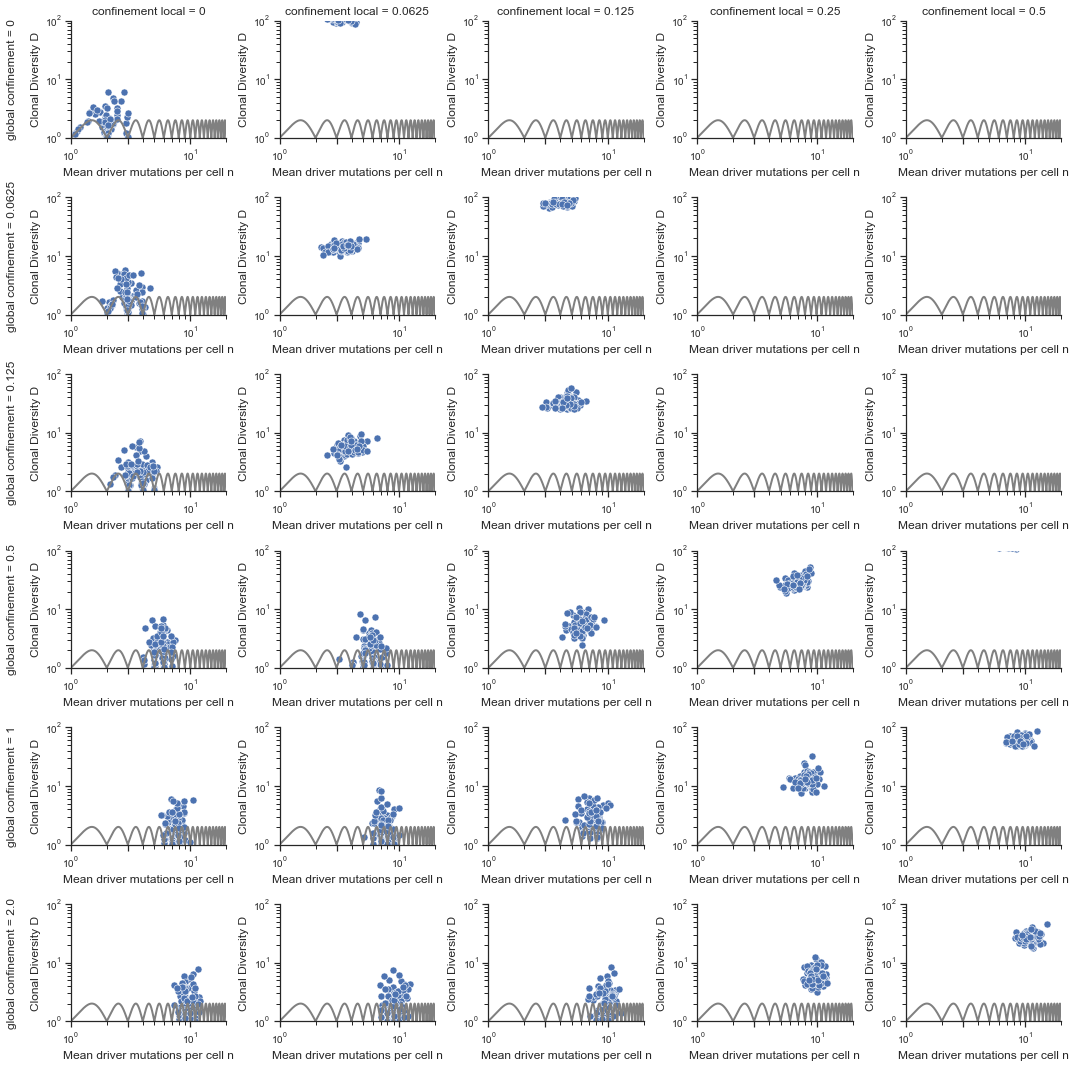

In [47]:
cur_MutationProb = 1e-5
cur_FitnessMean = 0.1

fig, axss = plt.subplots(figsize=(15, 15), facecolor='white',
                         nrows=len(selection_confinement_global), ncols=len(selection_confinement_local))

for cur_Confinement_global, axs in zip(selection_confinement_global, axss):
    for cur_Confinement_local, ax in zip(selection_confinement_local, axs):

        ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2, label='Sweeps')
        cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local) & (
            confinement_data_df['MutationProb'] == cur_MutationProb) & (confinement_data_df['FitnessMean'] == cur_FitnessMean)]
        sns.scatterplot(data=cur_data, x='MeanDriversPerCell', y='ClonalDiversity', s=50, ax=ax, color='C0',
                        legend=False)

        ax.set_ylabel('Clonal Diversity D')
        ax.set_xlabel('Mean driver mutations per cell n')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1, 20)
        ax.set_ylim(1, 100)
        ax.set_xticks([1, 3, 10])
        ax.set_yticks([1, 10, 100])

for cur_Confinement_global, ax in zip(selection_confinement_global, axss[:, 0]):
    ax.set_ylabel(f'global confinement = {cur_Confinement_global}\n\nClonal Diversity D', fontsize=plotting_params['FONTSIZE_LARGE'])
for cur_Confinement_local, ax in zip(selection_confinement_local, axss[0, :]):
    ax.set_title(f'confinement local = {cur_Confinement_local}', fontsize=plotting_params['FONTSIZE_LARGE'])

# axss[0, -1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('final_figures/confinement_final_grid.png', bbox_inches='tight', dpi=350)
plt.show()

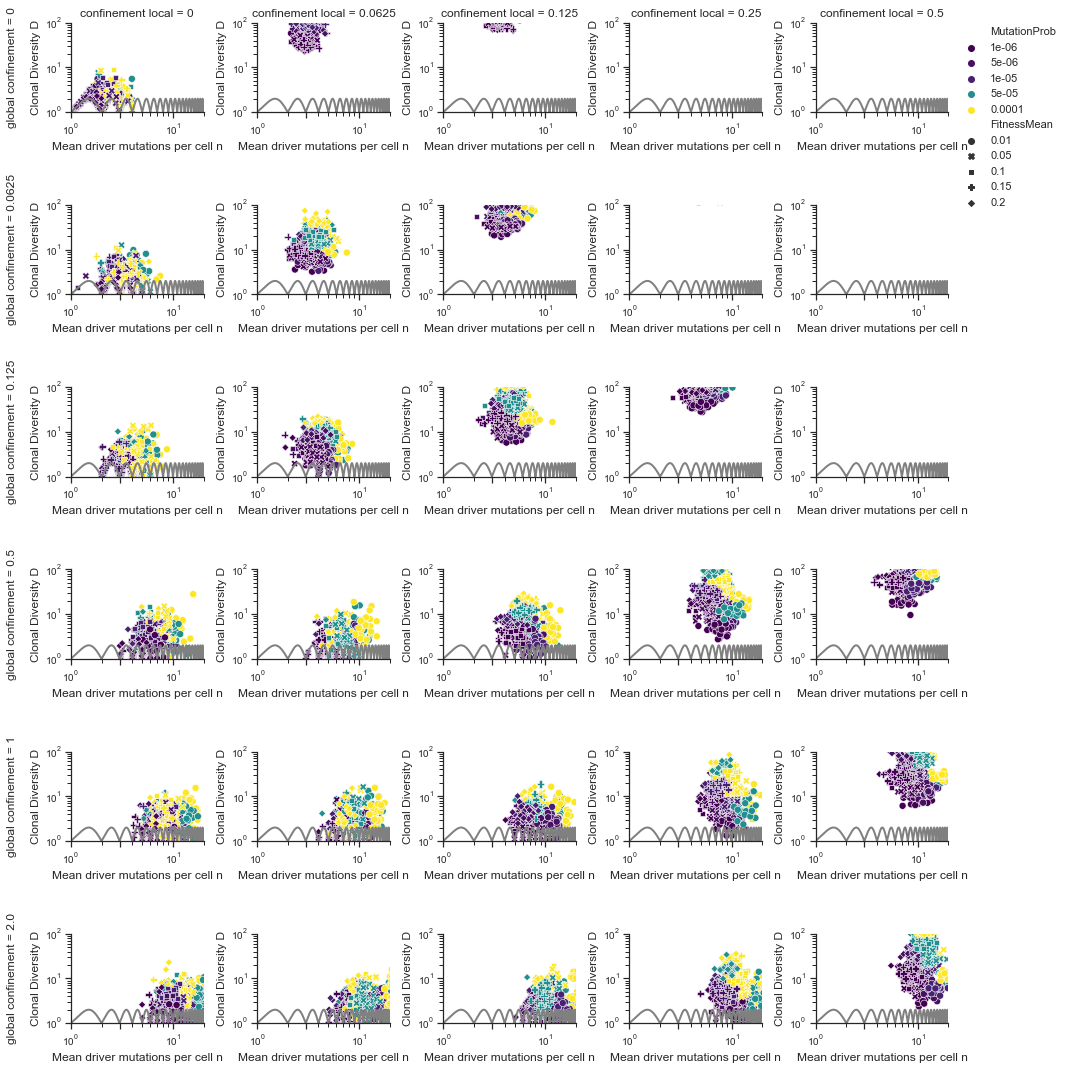

In [48]:
fig, axss = plt.subplots(figsize=(15, 15), facecolor='white',
                         nrows=len(selection_confinement_global), ncols=len(selection_confinement_local))

for cur_Confinement_global, axs in zip(selection_confinement_global, axss):
    for cur_Confinement_local, ax in zip(selection_confinement_local, axs):
        ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2)
        cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local)]
        sns.scatterplot(data=cur_data, x='MeanDriversPerCell', y='ClonalDiversity', hue='MutationProb',
                        style='FitnessMean', s=50, ax=ax, palette='viridis',
                        legend=((cur_Confinement_global == np.min(selection_confinement_global)) and (cur_Confinement_local == np.max(selection_confinement_local))))

        ax.set_ylabel('Clonal Diversity D')
        ax.set_xlabel('Mean driver mutations per cell n')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1, 20)
        ax.set_ylim(1, 100)
        ax.set_xticks([1, 3, 10])
        ax.set_yticks([1, 10, 100])


for cur_Confinement_global, ax in zip(selection_confinement_global, axss[:, 0]):
    ax.set_ylabel(f'global confinement = {cur_Confinement_global}\n\nClonal Diversity D', fontsize=plotting_params['FONTSIZE_LARGE'])
for cur_Confinement_local, ax in zip(selection_confinement_local, axss[0, :]):
    ax.set_title(f'confinement local = {cur_Confinement_local}', fontsize=plotting_params['FONTSIZE_LARGE'])

axss[0, -1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('final_figures/confinement_final_grid_MutationProb.png', bbox_inches='tight', dpi=350)
plt.show()

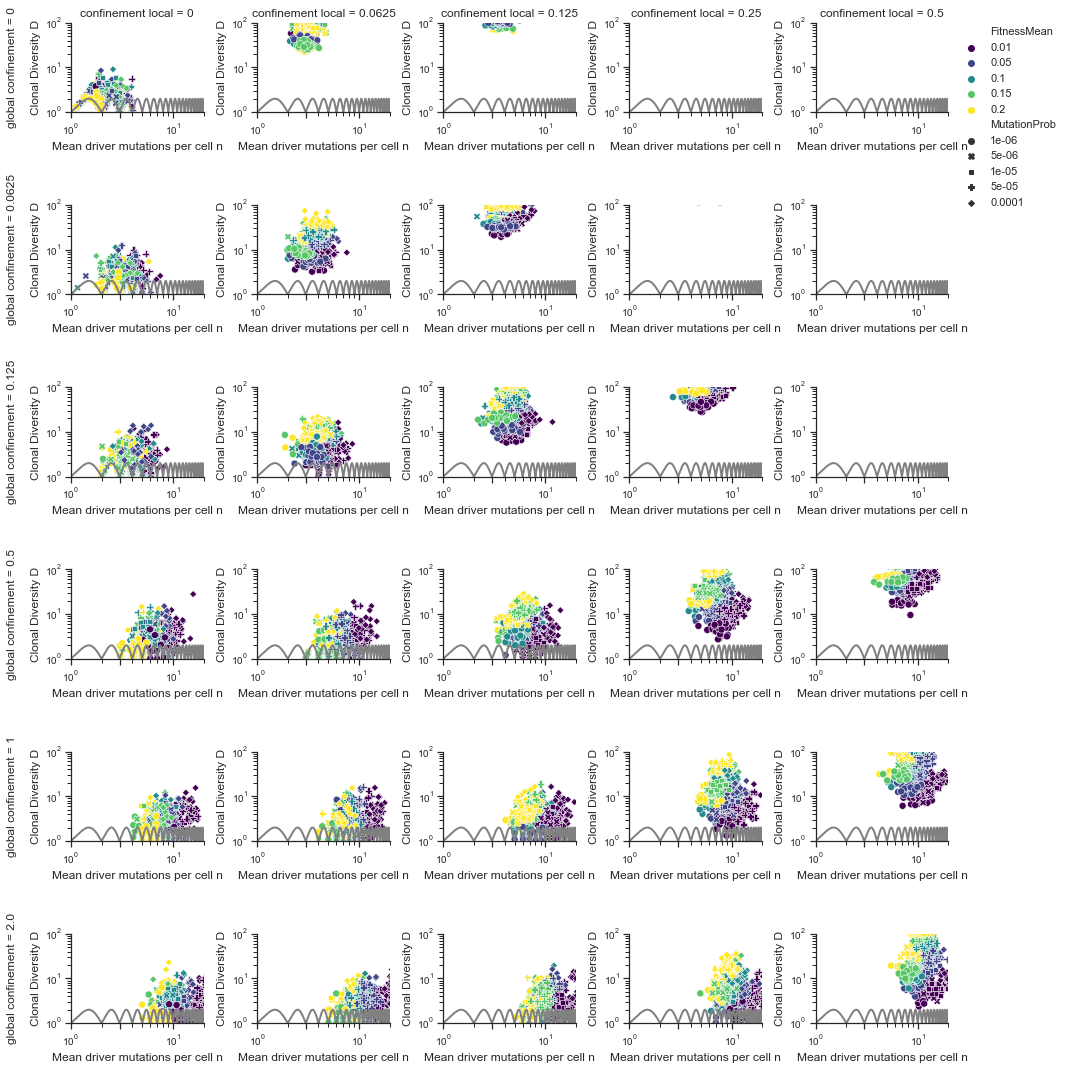

In [49]:
fig, axss = plt.subplots(figsize=(15, 15), facecolor='white',
                         nrows=len(selection_confinement_global), ncols=len(selection_confinement_local))

for cur_Confinement_global, axs in zip(selection_confinement_global, axss):
    for cur_Confinement_local, ax in zip(selection_confinement_local, axs):
        ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2)
        cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local)]
        sns.scatterplot(data=cur_data, x='MeanDriversPerCell', y='ClonalDiversity', hue='FitnessMean',
                        style='MutationProb', s=50, ax=ax, palette='viridis',
                        legend=((cur_Confinement_global == np.min(selection_confinement_global)) and (cur_Confinement_local == np.max(selection_confinement_local))))

        ax.set_ylabel('Clonal Diversity D')
        ax.set_xlabel('Mean driver mutations per cell n')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1, 20)
        ax.set_ylim(1, 100)
        ax.set_xticks([1, 3, 10])
        ax.set_yticks([1, 10, 100])


for cur_Confinement_global, ax in zip(selection_confinement_global, axss[:, 0]):
    ax.set_ylabel(f'global confinement = {cur_Confinement_global}\n\nClonal Diversity D', fontsize=plotting_params['FONTSIZE_LARGE'])
for cur_Confinement_local, ax in zip(selection_confinement_local, axss[0, :]):
    ax.set_title(f'confinement local = {cur_Confinement_local}', fontsize=plotting_params['FONTSIZE_LARGE'])

axss[0, -1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('final_figures/confinement_final_grid_FitnessMean.png', bbox_inches='tight', dpi=350)
plt.show()

## Fish plots for all confinement combinations

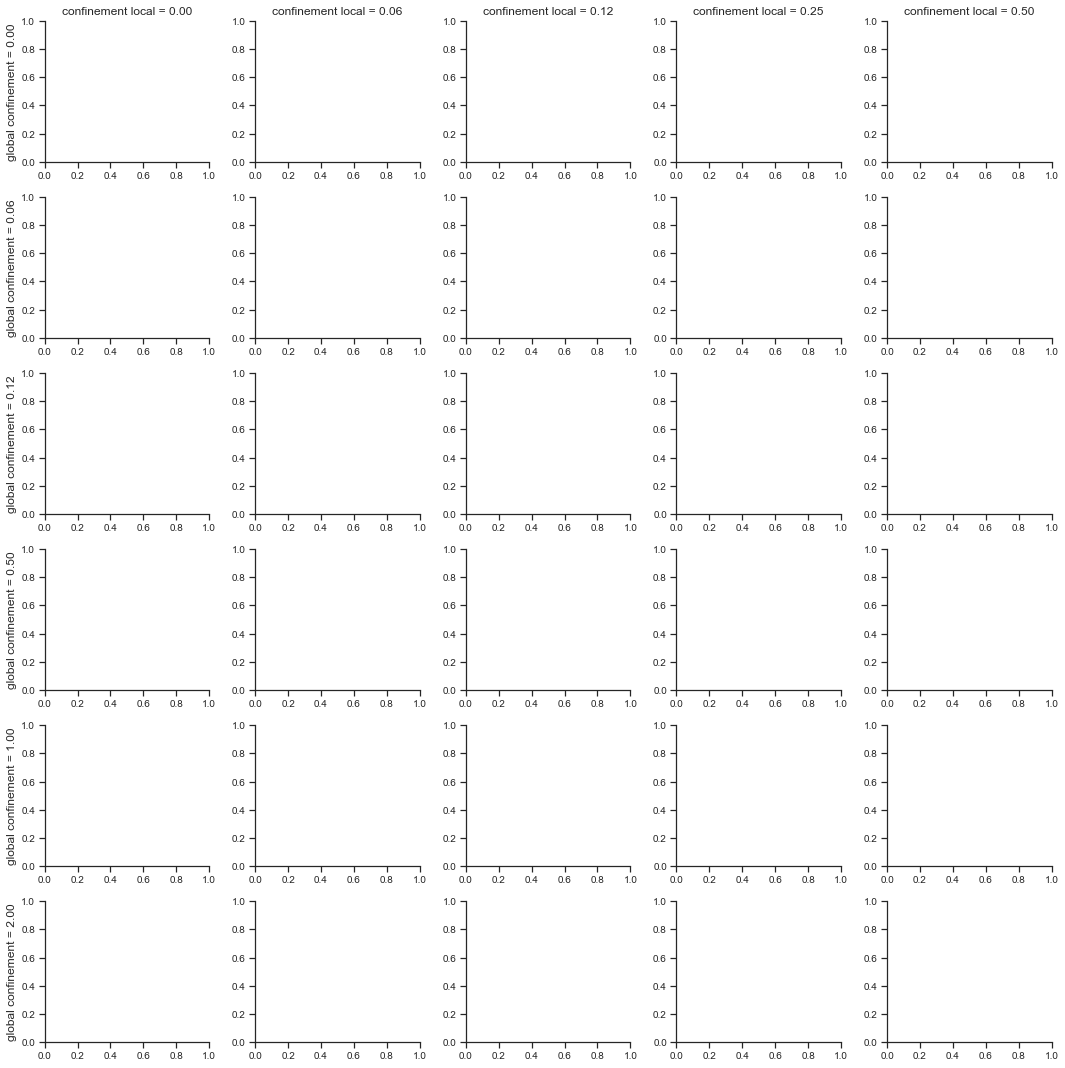

In [50]:
cur_selection_confinement_global = [0, 0.0625, 0.125, 0.5, 1, 2]
cur_selection_confinement_local = [0, 0.0625, 0.125, 0.25, 0.5]

fig, axss = plt.subplots(figsize=(15, 15), facecolor='white',
                         nrows=len(cur_selection_confinement_global), ncols=len(cur_selection_confinement_local))

for cur_Confinement_global, axs in zip(cur_selection_confinement_global, axss):
    for cur_Confinement_local, ax in zip(cur_selection_confinement_local, axs):
        if ((cur_Confinement_global, cur_Confinement_local) not in fish_plot_data.keys() or
             fish_plot_data[(cur_Confinement_global, cur_Confinement_local)] is None):
            continue
        plot_final_fish(fish_plot_data[(cur_Confinement_global, cur_Confinement_local)], ax)

for cur_Confinement_global, ax in zip(cur_selection_confinement_global, axss[:, 0]):
    ax.set_ylabel(f'global confinement = {cur_Confinement_global:.2f}')
for cur_Confinement_local, ax in zip(cur_selection_confinement_local, axss[0, :]):
    ax.set_title(f'confinement local = {cur_Confinement_local:.2f}')

plt.tight_layout()
plt.savefig('final_figures/fish_confinement_grid.png', bbox_inches='tight', dpi=350)

# Progresson over time (i.e. dependency on GenerationId)

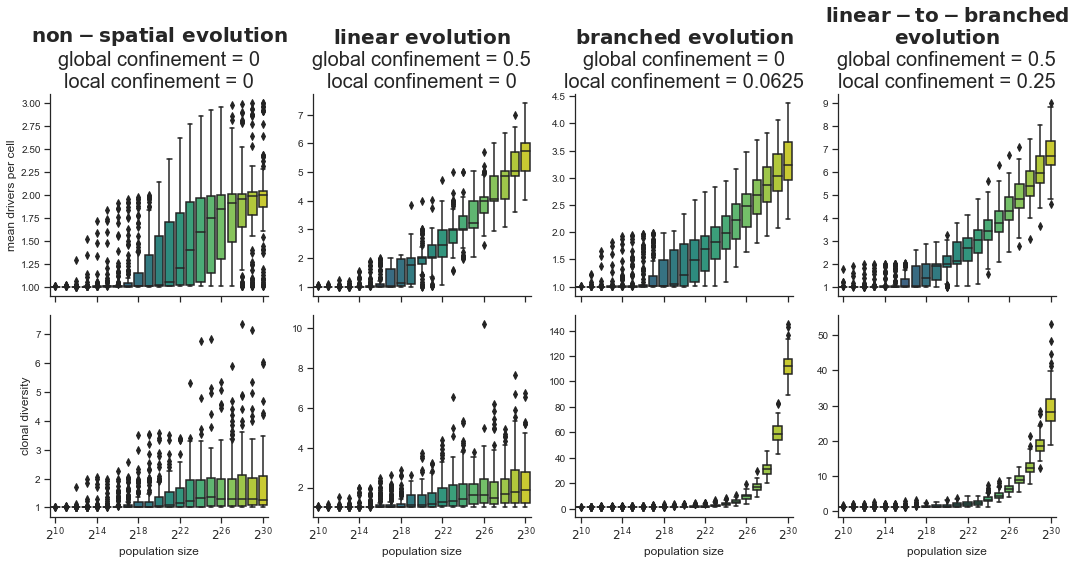

In [51]:
cur_MutationProb = 1e-5
cur_FitnessMean = 0.1

fig, axss = plt.subplots(ncols=4, nrows=2, figsize=(15, 8), sharex=True, sharey=False)

for col, axs in zip(['mean drivers per cell', 'clonal diversity'], axss):
    for ax, title, global_conf, local_conf in zip(
        axs, ['non-spatial\ evolution', 'linear\ evolution', 'branched\ evolution', 'linear-to-branched evolution'],
        [0, 0.5, 0, 0.5], [0, 0, 0.0625, 0.25]):

        metrics_over_time = all_metrics_over_time[(global_conf, local_conf)]
        sns.boxplot(
            data=metrics_over_time, x='GenerationId', y=col,
            palette='viridis', ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('')

        if col == 'mean drivers per cell':
            if title == 'linear-to-branched evolution':
                ax.set_title(
                    r'$\bf{' + 'linear-to-branched' + '}$' + '\n'
                    r'$\bf{' + 'evolution' + '}$'
                    f'\nglobal confinement = {global_conf}\nlocal confinement = {local_conf}',
                    fontsize=plotting_params['FONTSIZE_HUGE'])
            else:
                ax.set_title(
                    r'$\bf{' + f'{title}' + '}$'
                    f'\nglobal confinement = {global_conf}\nlocal confinement = {local_conf}',
                    fontsize=plotting_params['FONTSIZE_HUGE'])
        brackets = "{", "}"
        ax.set_xticklabels([f'$2^{brackets[0]}{int(x.get_text())+10}{brackets[1]}$' for x in ax.get_xticklabels()],
                            fontsize=plotting_params['FONTSIZE_LARGE'])
        ax.set_xticks(ax.get_xticks()[::4])

    axs[0].set_ylabel(col)

for ax in axss[-1, :]:
    ax.set_xlabel('population size')

plt.tight_layout()
plt.savefig(f'final_figures/metrics_over_time.png', bbox_inches='tight', dpi=350)
plt.show()

# Modes of Evolution

In [52]:
def label_func(x):
    if x is None or x == 'None' or 'internal' in x:
        return ''
    else:
        return f'  {x.split("-")[0]} ({int(x.split("-")[1]):.0e})'

def label_func_empty(x):
    return ''


def create_marker_size_dict(tree, samples):
    marker_size_dict = dict()
    for clade in tree.find_clades():
        if clade.name is None or clade.name == 'None' or 'internal' in clade.name or int(clade.name.split('-')[0]) not in samples:
            marker_size_dict[clade.name] = 0
        else:
            marker_size_dict[clade.name] = 10
    return marker_size_dict

def marker_size(x):
    if x is None or x == 'None' or 'internal' in x:
        return 1
    else:
        return 500

def marker_type(x):
    if x is None or x == 'None' or 'internal' in x:
        return 'o'
    if int(x.split('-')[1]) == 0:
        return 'X'
    else:
        return 'o'
    

0 0


MeanDriversPerCell    1.997939
ClonalDiversity       1.272350
dtype: float64

0.5 0


MeanDriversPerCell    5.721623
ClonalDiversity       1.881246
dtype: float64

0 0.0625


MeanDriversPerCell      3.232433
ClonalDiversity       112.008002
dtype: float64

1 0.25


MeanDriversPerCell     8.214707
ClonalDiversity       12.624323
dtype: float64

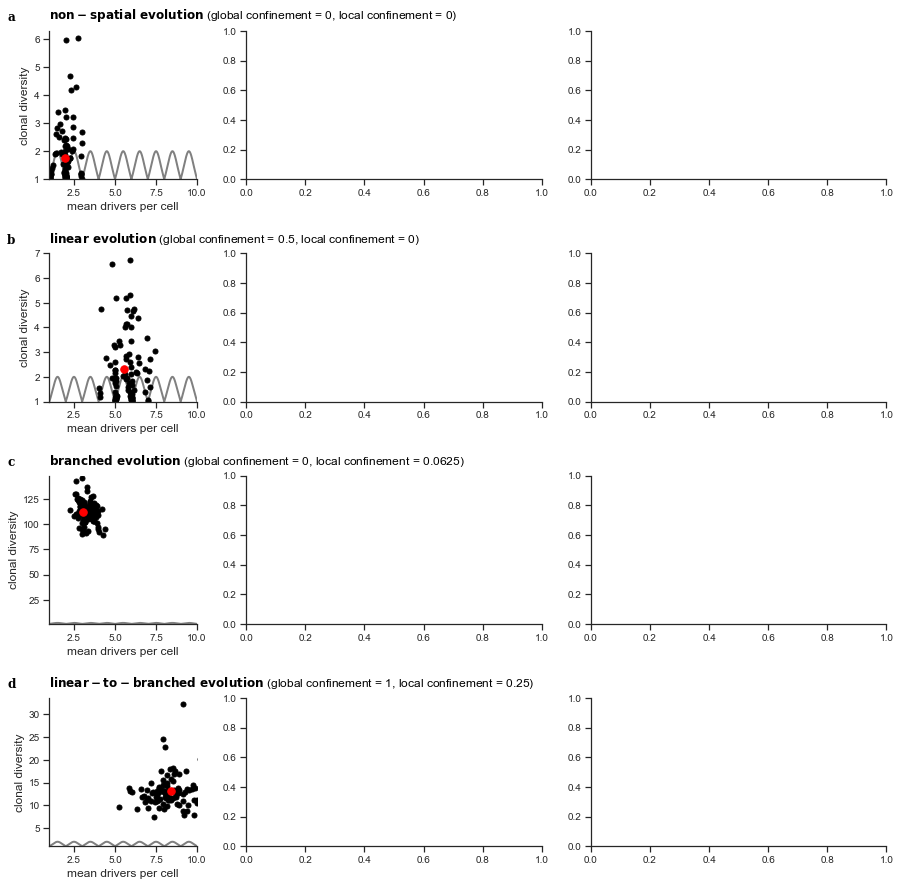

In [53]:
fig_width = 24
fig_height = 20

fig, axss = plt.subplots(ncols=3, nrows=4, figsize=(15, 15),
                        facecolor='white', gridspec_kw={'width_ratios': [1, 2, 2], 'hspace': 0.5})

for cur_Confinement_global, cur_Confinement_local, axs in zip([0, 0.5, 0, 1], [0, 0, 0.0625, 0.25], axss):

    # Scatter
    ax = axs[0]
    cur_MutationProb = 1e-5
    cur_FitnessMean = 0.1
    cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local) & (
        confinement_data_df['MutationProb'] == cur_MutationProb) & (confinement_data_df['FitnessMean'] == cur_FitnessMean)]
    print(cur_Confinement_global, cur_Confinement_local)
    display(cur_data[['MeanDriversPerCell', 'ClonalDiversity']].median())
    ax.plot(cur_data['MeanDriversPerCell'].values, cur_data['ClonalDiversity'].values, 'o', markersize=5, color='black')

    cur_id = most_representative_runs.loc[(most_representative_runs['Confinement_global']==cur_Confinement_global) & (most_representative_runs['Confinement_local']==cur_Confinement_local), 'RepeatId'].values[0]
    cur_data_best = cur_data.loc[cur_data['RepeatId'] == cur_id]
    ax.plot(cur_data_best['MeanDriversPerCell'].values, cur_data_best['ClonalDiversity'].values, 'o', markersize=7.5, color='red')

    ax.set_xlabel('mean drivers per cell')
    ax.set_ylabel('clonal diversity')
    ax.set_xlim(1, 10)
    ax.set_ylim(1, ax.get_ylim()[1])
    ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2, label='Sweeps', zorder=0)
    
    # Fish plot
    if (cur_Confinement_global, cur_Confinement_local) not in fish_plot_data:
        continue
    fish = fish_plot_data[(cur_Confinement_global, cur_Confinement_local)]
    fish_pop = fish[0]
    fish_colors = fish[2]
    pop = fish_pop.groupby('Id').sum()
    selected_clones = pop.index[pop.max(axis=1) > 0.01]
    fish_colors = fish_colors[fish_pop.index.isin(selected_clones)]
    fish_pop = fish_pop.loc[fish_pop.index.isin(selected_clones)]
    fish_pop = fish_pop / fish_pop.sum()
    plot_final_fish(tuple([fish_pop, fish[1], fish_colors, fish[3]]), axs[1])

    # Tree
    ax = axs[2]
    tree = deepcopy(tree_data[(cur_Confinement_global, cur_Confinement_local)])
    if tree is None:
        continue

    for clade in list(tree.find_clades(order="postorder")):
        if clade.name is None:
            continue
        if int(clade.name.split('-')[0]) not in selected_clones and clade.total_branch_length() == 1:
            ancestors = tree.get_path(clade)
            ancestor = ancestors[-2]
            ancestor.clades.remove(clade)

    normal_name = [x.name for x in tree.get_terminals() if x.name.split('-')[0] == '0'][0]

    colors = pd.DataFrame(fish_plot_data[(cur_Confinement_global, cur_Confinement_local)][2],
                        index=fish_plot_data[(cur_Confinement_global, cur_Confinement_local)][0].index)
    colors = colors.groupby(colors.index).first()
    colors.iloc[:, -1] = 1

    label_colors = dict()
    for node in tree.find_clades():
        if node.name is None:
            continue
        if 'internal' not in node.name and int(node.name.split('-')[0]) in colors.index:
            label_colors[node.name] = colors.loc[int(node.name.split('-')[0])].values
        else:
            label_colors[node.name] = 'black'

    marker_size_dict = create_marker_size_dict(tree, colors.index)
    # alive = {int(clade.name.split('-')[0]): True for clade in tree.find_clades() if clade.name is not None}
    alive = {int(clade.name.split('-')[0]): False for clade in tree.find_clades() if clade.name is not None}
    for clade in tree.get_terminals():
        # if clade.name is not None and '-' in clade.name and int(clade.name.split('-')[1]) > 0:
        if clade.name is not None and '-' in clade.name and int(clade.name.split('-')[1]) > 1000:
            alive[int(clade.name.split('-')[0])] = True
            for ancestor in tree.get_path(clade):
                if ancestor.name is not None and '-' in ancestor.name:
                    alive[int(ancestor.name.split('-')[0])] = True
    alive[0] = True

    f = plot_tree(
        tree, normal_name=normal_name, ax=ax, marker_type=marker_type,
        show_branch_lengths=False, marker_size=marker_size_dict,
        label_colors=label_colors, label_func=label_func_empty, 
        alive=alive
        )
    ax.set_axis_off()

for ax, label in zip(axss[:, 0], ['a', 'b', 'c', 'd']):
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, plt.gcf().dpi_scale_trans)
    ax.text(-0.15, 1.0, label, transform=ax.transAxes + trans,
            fontsize=plotting_params['FONTSIZE_LARGE'], color='black', va='bottom', ha='left', fontfamily='serif', fontweight='bold')

for ax, cur_Confinement_global, cur_Confinement_local, mode in zip(axss[:, 0], 
                [0, 0.5, 0, 1], [0, 0, 0.0625, 0.25], 
                ['non-spatial\ evolution', 'linear\ evolution', 'branched\ evolution', 'linear-to-branched\ evolution']):

    trans = mtransforms.ScaledTranslation(0, 7/72, plt.gcf().dpi_scale_trans)
    title = (r'$\bf{' + f'{mode}' + '}$ '
             f'(global confinement = {cur_Confinement_global}, local confinement = {cur_Confinement_local})')
    ax.text(0.0, 1.0, title, transform=ax.transAxes + trans,
            fontsize=plotting_params['FONTSIZE_LARGE'], color='black', va='bottom', ha='left')

# plt.tight_layout()
plt.savefig('final_figures/modes_of_evolution.png', bbox_inches='tight', dpi=350)
plt.savefig('final_figures/modes_of_evolution.tif', bbox_inches='tight', facecolor='white',
            dpi=350, format="tiff", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

# Calculate overlap with real data using minimum pairwise distance

In [54]:
def calc_min_pdm(data_1, data_2):

    pdm = pairwise_distances(data_1, data_2, metric='euclidean')
    return np.min(pdm, axis=0).mean() + np.min(pdm, axis=1).mean()

## Overlap between subtypes

In [55]:
datasets_overlap = pd.DataFrame(0, index=datasets, columns=datasets, dtype=float)

for ds1 in datasets:
    for ds2 in datasets:
        if ds1 != ds2:
            score = calc_min_pdm(
                    real_data.loc[real_data['dataset'] == ds1, ['n', 'D']].values,
                    real_data.loc[real_data['dataset'] == ds2, ['n', 'D']].values)
            datasets_overlap.loc[ds1, ds2] = score

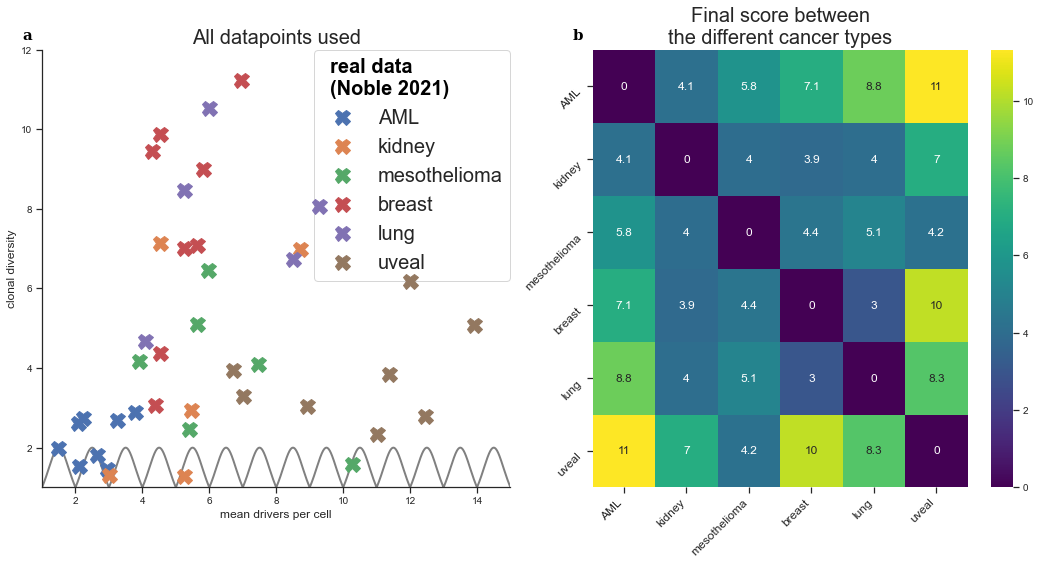

In [56]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 8))

ax = axs[0]
ymax_comparison = 20
ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2, zorder=0)

for j, dataset in enumerate(datasets):
    if dataset=='breast':
        continue
    m1 = real_data.loc[real_data['dataset'] == dataset, 'n'].values
    m2 = real_data.loc[real_data['dataset'] == dataset, 'D'].values

    if j == 0:
        ax.plot([], color='none', label='real data\n(Noble 2021)')
    ax.plot(m1, m2, 'X', color=f'C{j}', markersize=15, label=f'{dataset if dataset != "breast_SC" else "breast"}', zorder=10)

ax.set_xlabel('mean drivers per cell')
ax.set_ylabel('clonal diversity')
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(1, 15)
ax.set_ylim(1, 12)

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
legend = ax.legend(loc='upper right', borderaxespad=0.,
                   fontsize=plotting_params['FONTSIZE_HUGE'], facecolor='white', frameon=True)

for item, label in zip(legend.legendHandles, legend.texts):
    if label._text in ['real data\n(Noble 2021)']:
        # width=item.get_window_extent(fig.canvas.get_renderer()).width
        # label.set_position((-2*width,0))
        label.set_ha('left')
        label.set_position((-48, 0))
        label.set_fontsize(plotting_params['FONTSIZE_HUGE'])
        label.set_fontweight('bold')
        label.set_color('black')
ax.set_title('All datapoints used', fontsize=plotting_params['FONTSIZE_HUGE'])


ax = axs[1]
sns.heatmap(datasets_overlap, annot=True, cmap='viridis', ax=ax)
ax.set_xticklabels([x if x.get_text() != 'breast_SC' else 'breast' for x in ax.get_xticklabels()], rotation=45, ha='right', fontsize=plotting_params['FONTSIZE_LARGE'])
ax.set_yticklabels([x if x.get_text() != 'breast_SC' else 'breast' for x in ax.get_yticklabels()], rotation=45, va='top', fontsize=plotting_params['FONTSIZE_LARGE'])
ax.set_title('Final score between\nthe different cancer types',
             fontsize=plotting_params['FONTSIZE_HUGE'])

label_axes(axs)
plt.tight_layout()
plt.savefig('final_figures/overlap_between_cancer_types.png', bbox_inches='tight', facecolor='white')
plt.show()


## Our simulations

In [57]:
# cur_MutationProb = total.reset_index()['MutationProb'].iloc[0]
# cur_FitnessMean = total.reset_index()['FitnessMean'].iloc[0]
cur_MutationProb = 1e-5
cur_FitnessMean = 0.1

type_spec_res_best = dict()

for dataset in tqdm(real_data['dataset'].unique()):
    cur_real_data = real_data.loc[real_data['dataset'] == dataset]

    cur_res = pd.DataFrame(
        columns=['score'],
        index=pd.MultiIndex.from_tuples(
            [], names=['Confinement_local', 'Confinement_global']))

    # 0.0625 is indistinguishable from 0.125
    for cur_Confinement_global in [x for x in confinement_data_df['Confinement_global'].unique() if x!=0.0625]:
        for cur_Confinement_local in [x for x in confinement_data_df['Confinement_local'].unique() if x!=0.0625]:
            
            cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local) & (
                confinement_data_df['MutationProb'] == cur_MutationProb) & (confinement_data_df['FitnessMean'] == cur_FitnessMean)]
            if np.any(np.isnan(cur_data[['MeanDriversPerCell', 'ClonalDiversity']].values)) or len(cur_data[['MeanDriversPerCell', 'ClonalDiversity']].values) == 0:
                continue
            score = calc_min_pdm(
                cur_real_data[['n', 'D']].values,
                cur_data[['MeanDriversPerCell', 'ClonalDiversity']].values)

            cur_res.loc[(cur_Confinement_local, cur_Confinement_global), :] = [score]

    type_spec_res_best[dataset] = cur_res

100%|██████████| 7/7 [00:00<00:00, 14.86it/s]


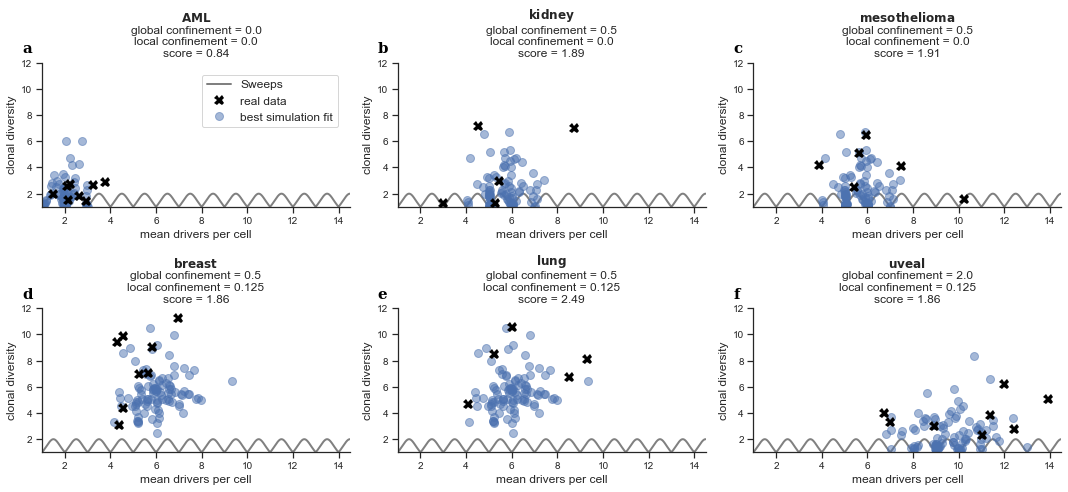

In [58]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 7), facecolor='white')
axs = axs

for j, (dataset, ax) in enumerate(zip(datasets, axs.flat)):
    m1 = real_data.loc[real_data['dataset'] == dataset, 'n'].values
    m2 = real_data.loc[real_data['dataset'] == dataset, 'D'].values

    ax.plot(m1, m2, 'X', color=f'black', markersize=10, zorder=10, markeredgewidth=0)

for j, (dataset, ax) in enumerate(zip(datasets, axs.flat)):
    cur_sorted_res = type_spec_res_best[dataset].sort_values('score', ascending=True).reset_index()

    cur_MutationProb = 1e-5
    cur_FitnessMean = 0.1
    cur_Confinement_local = cur_sorted_res['Confinement_local'].iloc[0]
    cur_Confinement_global = cur_sorted_res['Confinement_global'].iloc[0]
    cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local) & (
        confinement_data_df['MutationProb'] == cur_MutationProb) & (confinement_data_df['FitnessMean'] == cur_FitnessMean)]
    m1 = cur_data['MeanDriversPerCell'].values
    m2 = cur_data['ClonalDiversity'].values

    ax.plot(m1, m2, 'o', color=f'C0', markersize=8, alpha=0.5,
            # label=f'{dataset}\n(global conf = {cur_Confinement_global:.1f}, local conf = {cur_Confinement_local:.1f})'
            )
        
    score = type_spec_res_best[dataset].loc[(cur_Confinement_local, cur_Confinement_global), 'score']
    ax.set_title(
        r'$\bf{' + f'{dataset.replace("_SC", "")}' + '}$'
        f'\nglobal confinement = {cur_Confinement_global}\nlocal confinement = {cur_Confinement_local}\nscore = {score:.2f}',
        fontsize=plotting_params['FONTSIZE_LARGE'])

for ax in axs.flat:
    ax.set_xlim(1, 14.5)
    ax.set_ylim(1, 12)
    ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2, label='Sweeps', zorder=0)
    # ax.fill_between(linex[linex < 2], maxy[linex < 2], (linex < 2).sum() * [topy], color='grey',
    #                 linewidth=2, label='max value', alpha=0.25)
    ax.set_xlabel('mean drivers per cell')
    ax.set_ylabel('clonal diversity')
    

axs[0, 0].plot([], 'X', color=f'black', markersize=10, linestyle='none',
               label='real data', markeredgewidth=0)
axs[0, 0].plot([], 'o', color=f'C0', markersize=8, alpha=0.5, linestyle='none', label='best simulation fit')
legend = axs[0, 0].legend(loc='upper right', borderaxespad=1., frameon=True,
                          fontsize=plotting_params['FONTSIZE_LARGE'])
# legend = axs[0, -1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20)
label_axes(axs)

plt.tight_layout()
plt.savefig('final_figures/all_best_fits.png', bbox_inches='tight', dpi=350, facecolor='white')
plt.savefig('final_figures/all_best_fits.tif', bbox_inches='tight', facecolor='white',
            dpi=350 / 15 * 7, format="tiff", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

## Fit Noble simulations to real data

In [59]:
noble_type_spec_res = dict()

for dataset in tqdm(real_data['dataset'].unique()):
    cur_real_data = real_data.loc[real_data['dataset'] == dataset]

    cur_res = pd.DataFrame(
        columns=['score'],
        index=pd.MultiIndex.from_tuples(
            [], names=['label', 'K', 'mu_driver_birth', 's_driver_birth']))

    for cur_K in noble_combined['K'].unique():
        for cur_mu_driver_birth in noble_combined['mu_driver_birth'].unique():
            for cur_s_driver_birth in noble_combined['s_driver_birth'].unique():
                for cur_label in noble_combined['label'].unique():

                    cur_data = noble_combined.loc[(noble_combined['s_driver_birth'] == cur_s_driver_birth) & (
                        noble_combined['K'] == cur_K) & (noble_combined['mu_driver_birth'] == cur_mu_driver_birth) & (noble_combined['label'] == cur_label)]
                    if np.any(np.isnan(cur_data[['Drivers', 'DriverDiversity']].values)) or len(cur_data[['Drivers', 'DriverDiversity']].values) == 0:
                        continue
                    score = calc_min_pdm(
                        cur_real_data[['n', 'D']].values,
                        cur_data[['Drivers', 'DriverDiversity']].values)

                    cur_res.loc[cur_label, cur_K, cur_mu_driver_birth,
                                cur_s_driver_birth] = [score]

    noble_type_spec_res[dataset] = cur_res


100%|██████████| 7/7 [00:01<00:00,  4.20it/s]


## Combine ours and noble

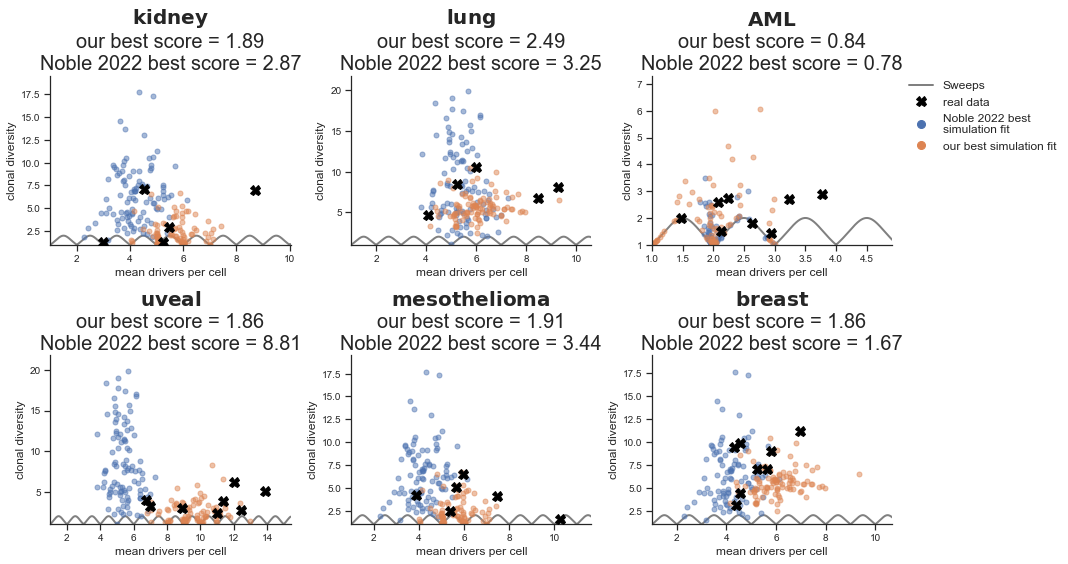

In [60]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 8), facecolor='white')
axs = axs


for j, (dataset, ax) in enumerate(zip([x for x in noble_type_spec_res.keys() if x!='breast'], axs.flat)):
    m1 = real_data.loc[real_data['dataset'] == dataset, 'n'].values
    m2 = real_data.loc[real_data['dataset'] == dataset, 'D'].values

    if j == 0:
        ax.plot([], color='none', label='real data (Noble 2021)')
    ax.plot(m1, m2, 'X', color=f'black', markersize=10, zorder=10,
            # label=f'{dataset}'
            )


for j, (dataset, ax) in enumerate(zip([x for x in noble_type_spec_res.keys() if x!='breast'], axs.flat)):
    cur_sorted_res = noble_type_spec_res[dataset].sort_values('score', ascending=True).reset_index()
    if j == 0:
        ax.plot([], color='none', label='best fit (Noble simulations)')


    cur_label = cur_sorted_res['label'].iloc[0]
    cur_K = cur_sorted_res['K'].iloc[0]
    cur_mu_driver_birth = cur_sorted_res['mu_driver_birth'].iloc[0]
    cur_s_driver_birth = cur_sorted_res['s_driver_birth'].iloc[0]
    cur_data = noble_combined.loc[(noble_combined['s_driver_birth'] == cur_s_driver_birth) & (
        noble_combined['K'] == cur_K) & (noble_combined['mu_driver_birth'] == cur_mu_driver_birth) & (noble_combined['label'] == cur_label)]
    m1 = cur_data['Drivers'].values
    m2 = cur_data['DriverDiversity'].values

    noble_score = noble_type_spec_res[dataset].loc[(cur_label, cur_K, cur_mu_driver_birth, cur_s_driver_birth), 'score']
    ax.plot(m1, m2, 'o', color=f'C0', markersize=5, alpha=0.5,
            )


    cur_sorted_res = type_spec_res_best[dataset].sort_values('score', ascending=True).reset_index()
    if j == 0:
        ax.plot([], color='none', label='best fit (our simulations)')

    cur_MutationProb = 1e-5
    cur_FitnessMean = 0.1
    cur_Confinement_local = cur_sorted_res['Confinement_local'].iloc[0]
    cur_Confinement_global = cur_sorted_res['Confinement_global'].iloc[0]
    cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) & (confinement_data_df['Confinement_local'] == cur_Confinement_local) & (
        confinement_data_df['MutationProb'] == cur_MutationProb) & (confinement_data_df['FitnessMean'] == cur_FitnessMean)]
    m1 = cur_data['MeanDriversPerCell'].values
    m2 = cur_data['ClonalDiversity'].values

    ax.plot(m1, m2, 'o', color=f'C1', markersize=5, alpha=0.5,
            )
    our_score = type_spec_res_best[dataset].loc[(cur_Confinement_local, cur_Confinement_global), 'score']
    ax.set_title(
        r'$\bf{' + f'{dataset.replace("_SC", "")}' + '}$'
        f'\nour best score = {our_score:.2f}\nNoble 2022 best score = {noble_score:.2f}',
        fontsize=plotting_params['FONTSIZE_HUGE'])

for ax in axs.flat:
    ylim = ax.get_ylim()[1]
    xlim = ax.get_xlim()[1]
    ax.set_xlim(1, xlim + 1)
    ax.set_ylim(1, ylim + 1)
    ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2, label='Sweeps', zorder=0)
    # ax.fill_between(linex[linex < 2], maxy[linex < 2], (linex < 2).sum() * [topy], color='grey',
    #                 linewidth=2, label='max value', alpha=0.25)
    ax.set_xlabel('mean drivers per cell')
    ax.set_ylabel('clonal diversity')

axs[0, -1].plot([], 'X', color=f'black', markersize=10, linestyle='none', label='real data')
axs[0, -1].plot([], 'o', color=f'C0', markersize=8, alpha=1, linestyle='none', label='Noble 2022 best\nsimulation fit')
axs[0, -1].plot([], 'o', color=f'C1', markersize=8, alpha=1, linestyle='none', label='our best simulation fit')
legend = axs[0, -1].legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                           borderaxespad=0., fontsize=plotting_params['FONTSIZE_LARGE'])

# label_axes(axs, fontsize=25)
plt.tight_layout()
plt.savefig('final_figures/all_best_fits_ours_and_Noble.png', bbox_inches='tight')
plt.show()

# Individual trajectories

In [61]:
example_trajectories = {
    (0, 0): [0, 25, 97, 74.],
    (0.5, 0): [67, 33, 54, 56],
    (0, 0.0625): [49, 1, 36, 98],
    (0.5, 0.25): [97, 24, 2, 12.]}

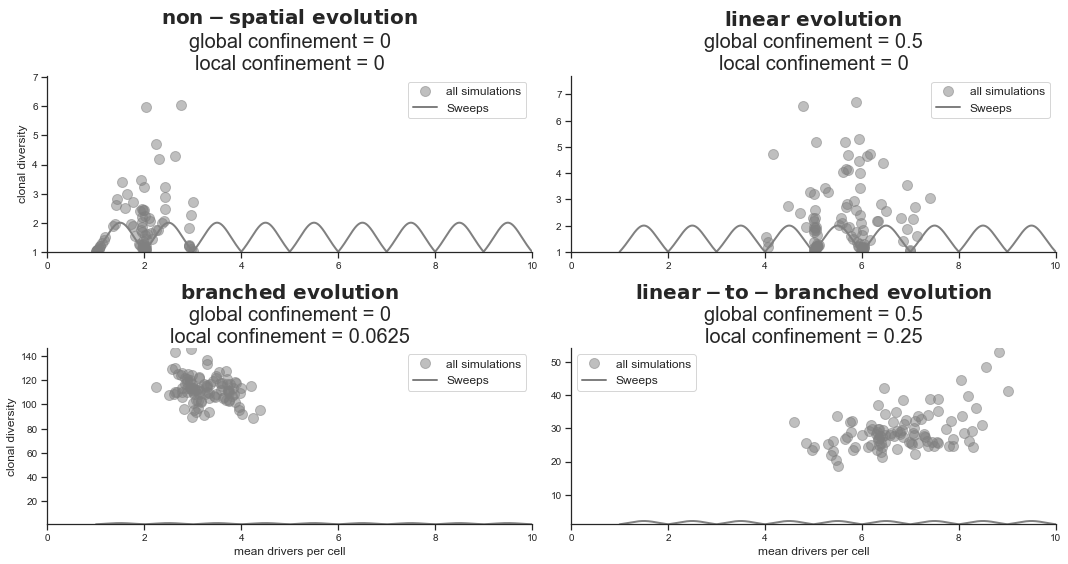

In [62]:
fig, axss = plt.subplots(figsize=(15, 8), facecolor='white',
                         nrows=2, ncols=2)

nr_examples = 4
cur_MutationProb = 1e-5
cur_FitnessMean = 0.1

for i, ax, title, cur_Confinement_global, cur_Confinement_local in zip(
        range(4), axss.flatten(), ['non-spatial\ evolution', 'linear\ evolution',
                                   'branched\ evolution', 'linear-to-branched\ evolution'],
        [0, 0.5, 0, 0.5], [0, 0, 0.0625, 0.25]):

    cur_samples = example_trajectories[(cur_Confinement_global, cur_Confinement_local)]
    cur_data = confinement_data_df.loc[(confinement_data_df['Confinement_global'] == cur_Confinement_global) &
                                       (confinement_data_df['Confinement_local'] == cur_Confinement_local) &
                                       (confinement_data_df['MutationProb'] == cur_MutationProb) &
                                       (confinement_data_df['FitnessMean'] == cur_FitnessMean)]
    cur_data = cur_data.loc[~cur_data.isna().any(axis=1)]
    if len(cur_data) == 0:
        continue
    ax.set_xlim(1, cur_data['MeanDriversPerCell'].max() + 1)
    ax.set_ylim(1, cur_data['ClonalDiversity'].max() + 1)

    ax.plot(cur_data['MeanDriversPerCell'], cur_data['ClonalDiversity'], 'o', label='all simulations',
            markersize=10, color='grey', alpha=0.5, zorder=0)

    for i, r in enumerate(cur_samples):
        if (cur_Confinement_global, cur_Confinement_local, i) not in trajectories:
            continue
        (full_population, population_df) = trajectories[(
            cur_Confinement_global, cur_Confinement_local, i)]
        clonal_diversity = (1 / (population_df**2).sum(axis=0))
        cur_data_sample = cur_data.loc[cur_data['RepeatId'] == r]
        clonal_diversity.loc[len(clonal_diversity)] = cur_data_sample['ClonalDiversity'].values[-1]
        driver_dict = full_population.groupby('Id')['Drivers'].mean()
        drivers = population_df.copy()
        drivers.loc[:] = 0
        for subclone in driver_dict.index:
            drivers.loc[subclone, :] = driver_dict[subclone]
        drivers = np.sum(drivers.values * population_df.values, axis=0)
        drivers = np.append(drivers, cur_data_sample['MeanDriversPerCell'].values[-1])

        ax.plot(drivers, clonal_diversity.values, '-', lw=3, color=f'C{i}')
        ax.plot(drivers[-1], clonal_diversity.values[-1], 'o',
                markersize=20, color=f'C{i}')
        ax.plot([], 'o',
                label=f'example {i+1}',
                markersize=15, color=f'C{i}')

    ax.set_title(
        r'$\bf{' + f'{title}' + '}$'
        f'\nglobal confinement = {cur_Confinement_global}\nlocal confinement = {cur_Confinement_local}',
        fontsize=plotting_params['FONTSIZE_HUGE'])

    ax.set_xlim(0, 10)
    ax.plot(linex, sweeps_func(linex), color='grey', linewidth=2, label='Sweeps', zorder=0)
    ax.legend(fontsize=plotting_params['FONTSIZE_LARGE'], frameon=True)

for ax in axss[-1, :]:
    ax.set_xlabel('mean drivers per cell')
for ax in axss[:, 0]:
    ax.set_ylabel('clonal diversity')

plt.tight_layout()
plt.savefig('final_figures/trajectories_modes_evolution_4_wout_fluctuation.png',
            dpi=350, bbox_inches='tight')
plt.show()

# Robustness analysis

In [63]:
all_scores = dict()

for dataset in datasets:
    cur_scores = pd.DataFrame(index=range_MutationProb, columns=range_FitnessMean)
    cur_sorted_res = type_spec_res_best[dataset].sort_values('score', ascending=True).reset_index()
    cur_Confinement_local = cur_sorted_res['Confinement_local'].iloc[0]
    cur_Confinement_global = cur_sorted_res['Confinement_global'].iloc[0]

    cur_real_data = real_data.loc[real_data['dataset']==dataset]

    for cur_MutationProb in range_MutationProb:
        for cur_FitnessMean in range_FitnessMean:
            cur_data = confinement_data_df.loc[
                (confinement_data_df['Confinement_global'] == cur_Confinement_global) &
                (confinement_data_df['Confinement_local'] == cur_Confinement_local) &
                (confinement_data_df['MutationProb'] == cur_MutationProb) &
                (confinement_data_df['FitnessMean'] == cur_FitnessMean)]

            score = calc_min_pdm(
                cur_real_data[['n', 'D']].values,
                cur_data[['MeanDriversPerCell', 'ClonalDiversity']].values)
            cur_scores.loc[cur_MutationProb, cur_FitnessMean] = score

    all_scores[dataset] = cur_scores

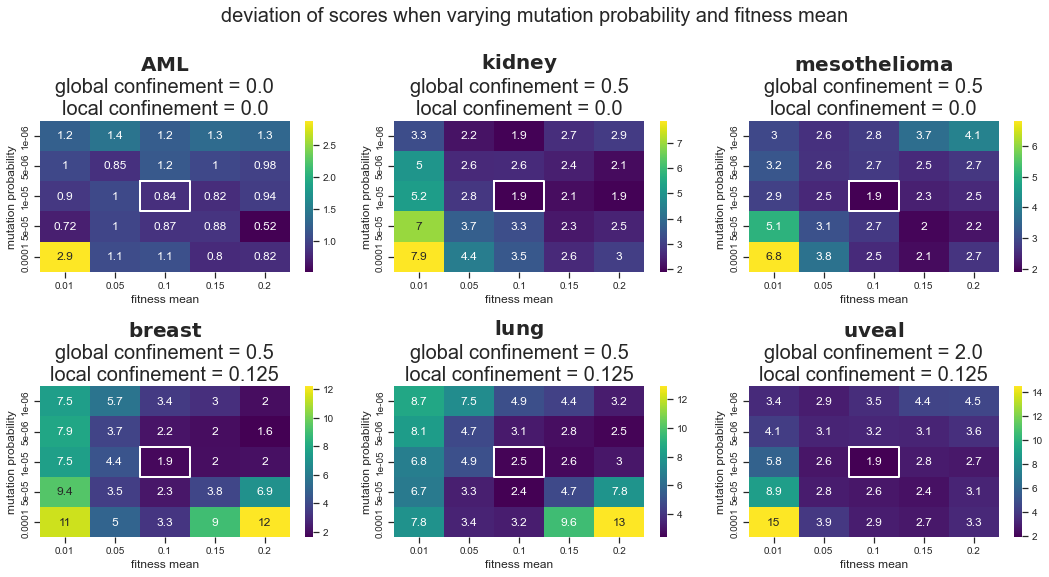

In [64]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 8), facecolor='white', sharex=False, sharey=False)

for ax, dataset in zip(axs.flat, all_scores):
    cur_sorted_res = type_spec_res_best[dataset].sort_values('score', ascending=True).reset_index()
    cur_Confinement_local = cur_sorted_res['Confinement_local'].iloc[0]
    cur_Confinement_global = cur_sorted_res['Confinement_global'].iloc[0]

    sns.heatmap(all_scores[dataset].astype(float), ax=ax, cmap='viridis', annot=True)
    ax.set_xlabel('fitness mean')
    ax.set_ylabel('mutation probability')
    ax.set_xticklabels(ax.get_xticklabels())
    ax.set_yticklabels(ax.get_yticklabels())

    ax.set_title(
        r'$\bf{' + f'{dataset.replace("_SC", "")}' + '}$'
        f'\nglobal confinement = {cur_Confinement_global}\nlocal confinement = {cur_Confinement_local}',
        fontsize=plotting_params['FONTSIZE_HUGE'])

    plt.suptitle('deviation of scores when varying mutation probability and fitness mean',
                 fontsize=plotting_params['FONTSIZE_HUGE'], y=1.0)

    ax.plot([2, 3, 3, 2, 2], [2, 2, 3, 3, 2], color='white', lw=2)

plt.tight_layout()
plt.savefig('final_figures/score_deviation_mutprob_and_fitmean_varying_summary.png', bbox_inches='tight', dpi=350)

# Fitness dist and accumulation

In [65]:
key_FitnessDist = {0: "Constant", 1: "Normal", 2: "Exponential", 3: "Uniform"}
key_FitnessAcc = {0: "Mul", 1: "Add", 2: "ETH"}

key_rev_FitnessDist = {v: k for k, v in key_FitnessDist.items()}
key_rev_FitnessAcc = {v: k for k, v in key_FitnessAcc.items()}


## Shape of fitness dist

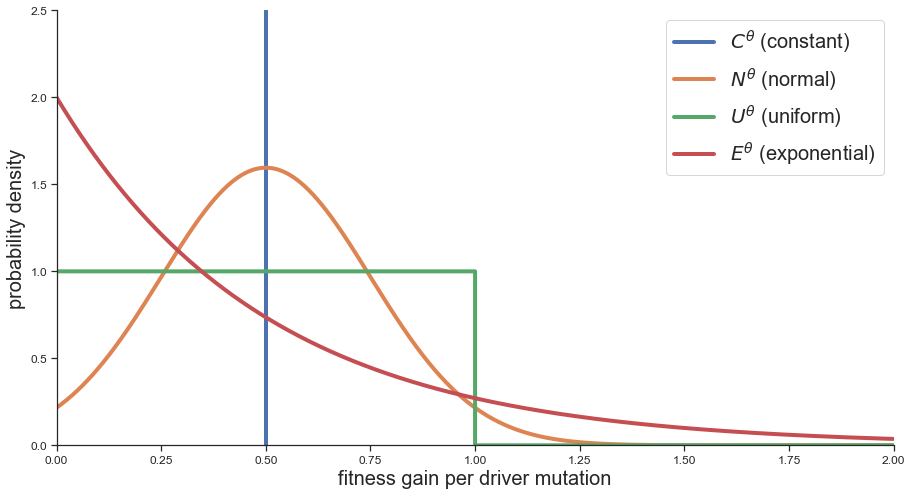

In [66]:
fitness_mean = 0.5
x = np.arange(0, 4*fitness_mean, 0.001)

uniform_dist = 1 / (2*fitness_mean) * np.ones_like(x)
uniform_dist[x > 2*fitness_mean] = 0
exponential_dist = expon.pdf(x, 0, fitness_mean)
beta_dist = beta.pdf(x, 1, 1/fitness_mean - 1)
normal_dist = norm.pdf(x, fitness_mean, 1/2 * fitness_mean)
constant_dist = np.zeros_like(x)
constant_dist[x == fitness_mean] = 20

lw = 4
plt.figure(figsize=(15, 8))
plt.axvline(fitness_mean, lw=lw, label='$C^{\\theta}$ (constant)')
plt.plot(x, normal_dist, lw=lw, label='$N^{\\theta}$ (normal)', color='C1')
plt.step(x, uniform_dist, lw=lw, label='$U^{\\theta}$ (uniform)', color='C2')
plt.plot(x, exponential_dist, lw=lw, label='$E^{\\theta}$ (exponential)', color='C3')
plt.legend(facecolor='w', frameon=True, fontsize=plotting_params['FONTSIZE_HUGE'])
plt.ylim(0, 2.5)
plt.xlim(0, 4*fitness_mean)
plt.xlabel('fitness gain per driver mutation', fontsize=plotting_params['FONTSIZE_HUGE'])
plt.ylabel('probability density', fontsize=plotting_params['FONTSIZE_HUGE'])
plt.xticks(fontsize=plotting_params['FONTSIZE_LARGE'])
plt.yticks(fontsize=plotting_params['FONTSIZE_LARGE'])
plt.savefig('final_figures/sup_fitness_functions.png', bbox_inches='tight', dpi=350)
plt.show()


## Fitness dist

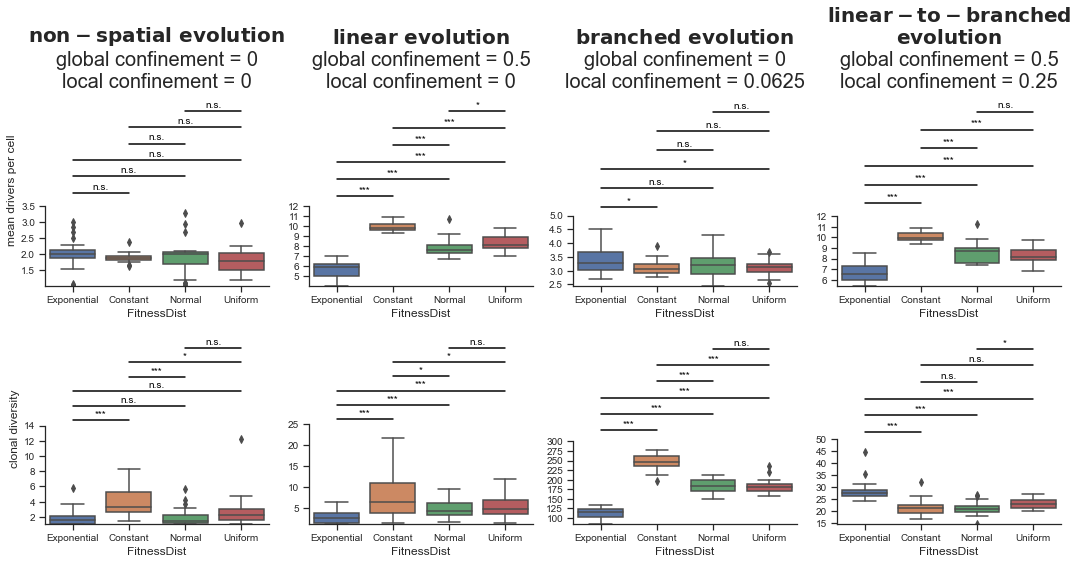

In [67]:
cur_MutationProb = 1e-5
cur_FitnessMean = 0.1

fig, axss = plt.subplots(ncols=4, nrows=2, figsize=(15, 8), sharex=False, sharey=False)

for i, col, axs in zip([0, 1], ['mean drivers per cell', 'clonal diversity'], axss):
    for ax, title, cur_Confinement_global, cur_Confinement_local in zip(
            axs, ['non-spatial\ evolution', 'linear\ evolution',
                  'branched\ evolution', 'linear-to-branched\ evolution'],
            [0, 0.5, 0, 0.5], [0, 0, 0.0625, 0.25]):

        cur_fitness_dist_data = fitness_dist_data.loc[(fitness_dist_data['Confinement_global'] == cur_Confinement_global) & (fitness_dist_data['Confinement_local'] == cur_Confinement_local) & (
                fitness_dist_data['MutationProb'] == cur_MutationProb) & (fitness_dist_data['FitnessMean'] == cur_FitnessMean)]

        plot_final_fitness(i, cur_fitness_dist_data, ax, h_scale=0.075, hl_scale=0.0, yshift=2)
        # ax.set_xlabel('')
        ax.set_ylabel('')

        if col == 'mean drivers per cell':
            if title == 'linear-to-branched\ evolution':
                ax.set_title(
                    r'$\bf{' + 'linear-to-branched' + '}$' + '\n'
                    r'$\bf{' + 'evolution' + '}$'
                    f'\nglobal confinement = {global_conf}\nlocal confinement = {local_conf}',
                    fontsize=plotting_params['FONTSIZE_HUGE'])
            else:
                ax.set_title(
                    r'$\bf{' + f'{title}' + '}$'
                    f'\nglobal confinement = {cur_Confinement_global}\nlocal confinement = {cur_Confinement_local}',
                    fontsize=plotting_params['FONTSIZE_HUGE'])

    axs[0].set_ylabel(col)

plt.tight_layout()
plt.savefig(f'final_figures/fitness_dist.png', bbox_inches='tight', dpi=350)
plt.show()

## Fitness acc

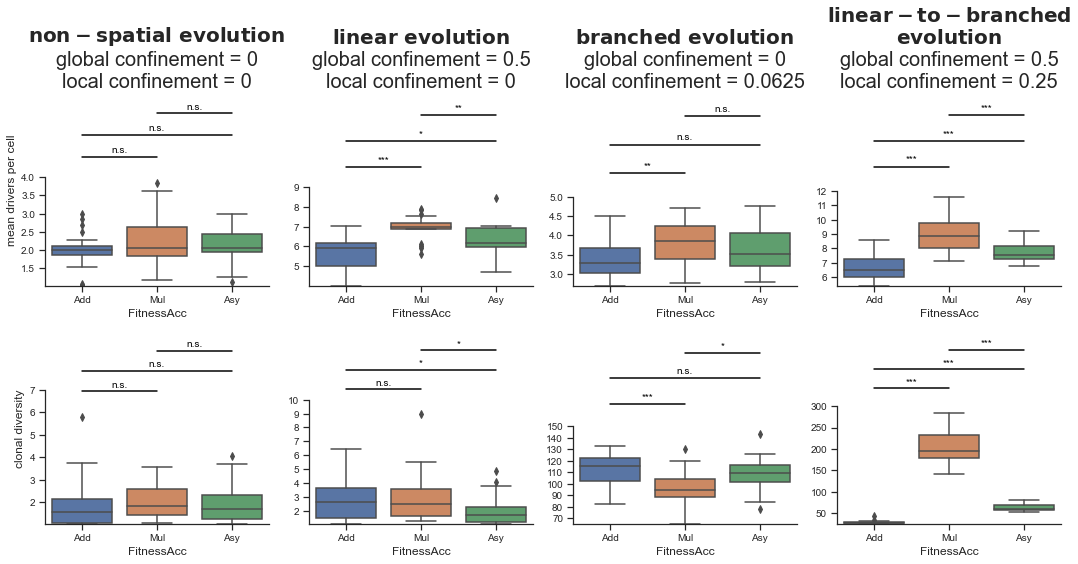

In [68]:
cur_MutationProb = 1e-5
cur_FitnessMean = 0.1

fig, axss = plt.subplots(ncols=4, nrows=2, figsize=(15, 8), sharex=False, sharey=False)

for i, col, axs in zip([0, 1], ['mean drivers per cell', 'clonal diversity'], axss):
    for ax, title, cur_Confinement_global, cur_Confinement_local in zip(
            axs, ['non-spatial\ evolution', 'linear\ evolution',
                  'branched\ evolution', 'linear-to-branched\ evolution'],
            [0, 0.5, 0, 0.5], [0, 0, 0.0625, 0.25]):

        cur_fitness_acc_data = fitness_acc_data.loc[(fitness_acc_data['Confinement_global'] == cur_Confinement_global) & (fitness_acc_data['Confinement_local'] == cur_Confinement_local) & (
            fitness_acc_data['MutationProb'] == cur_MutationProb) & (fitness_acc_data['FitnessMean'] == cur_FitnessMean)]

        plot_final_fitness(i, cur_fitness_acc_data, ax, h_scale=0.075,
                           hl_scale=0.0, yshift=2, col='FitnessAcc', order=['Add', 'Mul', 'Asy'])
        # ax.set_xlabel('')
        ax.set_ylabel('')

        if col == 'mean drivers per cell':
            if title == 'linear-to-branched\ evolution':
                ax.set_title(
                    r'$\bf{' + 'linear-to-branched' + '}$' + '\n'
                    r'$\bf{' + 'evolution' + '}$'
                    f'\nglobal confinement = {global_conf}\nlocal confinement = {local_conf}',
                    fontsize=plotting_params['FONTSIZE_HUGE'])
            else:
                ax.set_title(
                    r'$\bf{' + f'{title}' + '}$'
                    f'\nglobal confinement = {cur_Confinement_global}\nlocal confinement = {cur_Confinement_local}',
                    fontsize=plotting_params['FONTSIZE_HUGE'])

    axs[0].set_ylabel(col)

plt.tight_layout()
plt.savefig(f'final_figures/fitness_acc.png', bbox_inches='tight', dpi=350, facecolor='white')
plt.show()

In [69]:
def ratio(pop_total, pop_alive, conf):
    if pop_total == 0:
        return 0
    elif conf == 0:
        return 1
    else:
        return min(shell(pop_total, conf) / pop_alive, 1)
    
def shell(pop_total, conf):
    return pop_total - 4/3*np.pi * (core(pop_total, conf))**3
                                                   
def core(pop_total, conf):
    return max((3/4*(pop_total)/np.pi)**(1/3) - 1/conf, 0)

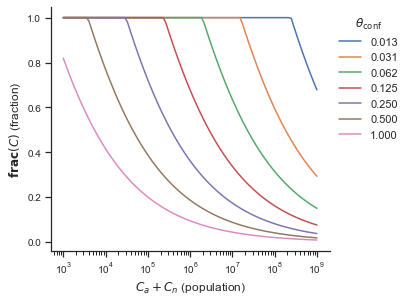

In [70]:
plt.figure(figsize=(5, 4.5))

# log scaled array from 0.01 to 1.0 with 16 steps
conf = [0.0125, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1]

# log scaled array from 1000 to 10^9 with 100 steps
pop = np.logspace(3, 9, 100)


# Plot
plt.xscale('log')
plt.xlabel(r'$C_a + C_n$ (population)')
plt.ylabel(r'${\bf {frac}}(C)$ (fraction)')
for con in conf:
    plt.plot(pop, np.array([ratio(p, p / 2, con) for p in pop]))

# create an artist for the legend
legend_elements = ['{:.3f}'.format(c) for c in conf]

# plot legend from the artist outside of the plot with anchor top right and text "confinement"
plt.legend(legend_elements, loc='upper left', title=r'$\theta_{\rm{conf}}$',  bbox_to_anchor=(1, 1))

# save the plot as a PDF
plt.savefig('final_figures/confinement.pdf', bbox_inches = 'tight')

# save the plot as a Png
plt.savefig('final_figures/confinement.png', bbox_inches = 'tight')

# Comparison of fitness accumulation functions

In [71]:
def sum_fit(iterations, value):
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] + value)
    return res     

def mul_fit(iterations, value):
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] * (1 + value))
    return res     

def eth_fit(iterations, value):
    MAX_FIT = 10
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] * (1 + value * (1 - res[-1] / MAX_FIT)))
    return res

def log_mul_fit(iterations, value):
    return [1 + np.log(x) for x in mul_fit(iterations, value)]

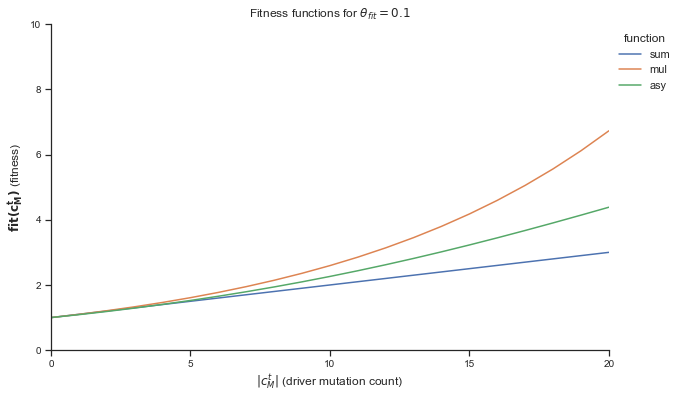

In [72]:
# set plot size to (16, 9)
plt.rcParams['figure.figsize'] = [10, 6]
# set font size to 16
plt.rcParams['font.size'] = 16

steps = list(range(0, 21))

fit = 0.1
plt.plot(steps, sum_fit(21, fit))
plt.plot(steps, mul_fit(21, fit))
plt.plot(steps, eth_fit(21, fit))

plt.ylabel(r'${\bf fit(c^t_M)}$ (fitness)')
plt.xlabel(r'$|c^t_M|$ (driver mutation count)')
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.legend(['sum', 'mul', 'asy'], loc='upper left', title='function',  bbox_to_anchor=(1, 1))

# title 
plt.title(r'Fitness functions for $\theta_{fit}=0.1$')
# set x ticks to [0,5,10,15,20]
plt.xticks([0,5,10,15,20])

# save the plot as a PNG and PDF   
plt.savefig('final_figures/fitness_functions.png', bbox_inches = 'tight')
plt.savefig('final_figures/fitness_functions.pdf', bbox_inches = 'tight')



# Homeostatic population

In [73]:
populations_df = pd.read_csv("./data/passengers/populations.csv")
parent_tree_df = pd.read_csv("./data/passengers/parent_tree.csv")

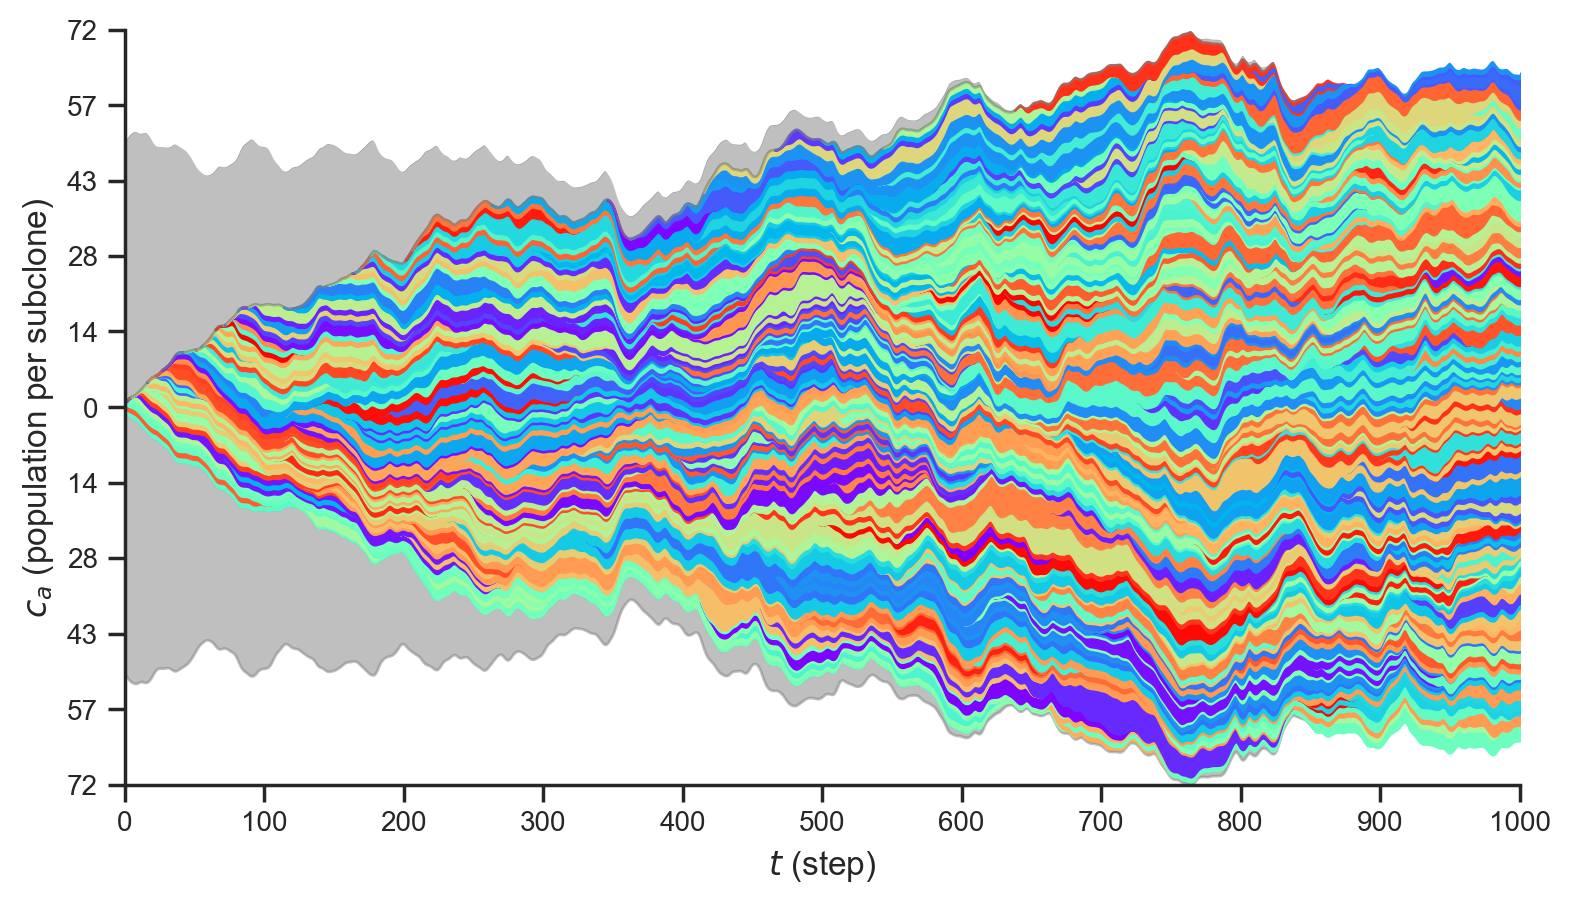

<Figure size 720x432 with 0 Axes>

In [74]:
data = process_data(populations_df, parent_tree_df, smooth=2, absolute=True)
width = 1920
height = 1080
dpi = 200
plt.figure(figsize=(width // dpi, height // dpi), dpi=dpi)
plt.xlabel(r'$t$ (step)')
plt.ylabel(r'$c_a$ (population per subclone)')
fish_plot(*data)
plt.show()

# save the plot as a PDF
plt.savefig('final_figures/passengers.pdf', bbox_inches='tight')

# save the plot as a Png
plt.savefig('final_figures/passengers.png', bbox_inches='tight')


# Performance Comparison

In [75]:
SMITH_conf_path = "./data/performance_SMITH_conf/"
tumopp_path = "./data/performance_tumopp/"
SMITH_no_path = "./data/performance_SMITH_no_conf/"

In [76]:
smith_list = []
SMITH_conf_files = os.listdir(SMITH_conf_path)
for file in SMITH_conf_files:
    # read file by lines
    with open(SMITH_conf_path + file, "r") as f:
        lines = f.readlines()
        for line in lines:
            # find if line matches the pattern "Total time: .*"
            if re.match("Total time: (.*)", line):
                time_str = re.match("Total time: (.*)", line).group(1)
                # parse time string from "hh:mm:ss.lll" to seconds
                parts = time_str.split(".")
                time = (sum(x * int(t) for x, t in zip([3600, 60, 1], parts[0].split(":"))) + float("0." + parts[1])) / 10
                file_count = file.split(".")[0]
                smith_list.append((file_count, time))              
smith_conf_data = pd.DataFrame(smith_list, columns=["size", "time"])
smith_conf_data["size"] = smith_conf_data["size"].astype('int')
smith_conf_data["time"] = smith_conf_data["time"].astype('float')
smith_conf_data



NameError: name 're' is not defined

In [ ]:
smith_list = []
SMITH_no_files = os.listdir(SMITH_no_path)
for file in SMITH_no_files:
    # read file by lines
    with open(SMITH_no_path + file, "r") as f:
        lines = f.readlines()
        for line in lines:
            # find if line matches the pattern "Total time: .*"
            if re.match("Total time: (.*)", line):
                time_str = re.match("Total time: (.*)", line).group(1)
                # parse time string from "hh:mm:ss.lll" to seconds
                parts = time_str.split(".")
                time = (sum(x * int(t) for x, t in zip([3600, 60, 1], parts[0].split(":"))) + float("0." + parts[1])) / 10
                file_count = file.split(".")[0]
                smith_list.append((file_count, time))                
smith_no_data = pd.DataFrame(smith_list, columns=["size", "time"])
smith_no_data["size"] = smith_no_data["size"].astype('int')
smith_no_data["time"] = smith_no_data["time"].astype('float')
smith_no_data




,size,time
0,10000,0.0476
1,100000,0.0395
2,1000000,0.0642
3,10000000,0.1446
4,100000000,0.2131
5,1000000000,8.9508


In [ ]:
tumopp_list = []
tumopp_files = [file for file in os.listdir(tumopp_path) if file.endswith(".out")]
for file in tumopp_files:
    # read file by lines
    with open(tumopp_path + file, "r") as f:
        lines = f.readlines()
        sum = 0
        for line in lines:
            # find if line matches the pattern "Total time: .*"
            if re.match("(\d*,\d*)", line):
                time_str = re.match("(\d*,\d*)", line).group(1).replace(",", ".")     
                sum += float(time_str)
        file_count = file.split(".")[0]      
        tumopp_list.append((file_count, sum / 10))
tumopp_data = pd.DataFrame(tumopp_list, columns=["size", "time"])
tumopp_data.head(20)

# set tumpop data columns to int, float
tumopp_data["size"] = tumopp_data["size"].astype('int')
tumopp_data["time"] = tumopp_data["time"].astype('float')
tumopp_data

,size,time
0,10000,0.4727
1,100000,8.2664
2,1000000,57.1776
3,10000000,2341.5443


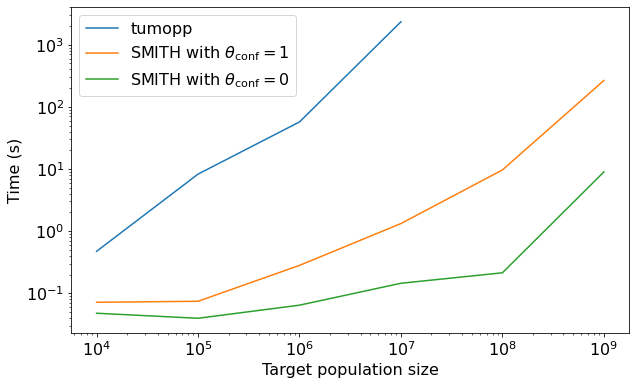

In [ ]:
plt.plot(tumopp_data["size"], tumopp_data["time"], label="tumopp")
plt.plot(smith_conf_data["size"], smith_conf_data["time"], label=r"SMITH with $\theta_{\rm{conf}} = 1$")
plt.plot(smith_no_data["size"], smith_no_data["time"], label=r"SMITH with $\theta_{\rm{conf}} = 0$")
# set y log scale
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Target population size")
plt.ylabel("Time (s)")
plt.legend()

# save the plot as a PDF
plt.savefig('final_figures/performance.pdf', bbox_inches = 'tight')

# save the plot as a Png
plt.savefig('final_figures/performance.png', bbox_inches = 'tight')